# Machine Learning
### Assignment 2

Final Report: Student Performance Classification using K-Nearest Neighbors (KNN)

1. ## Introduction
The dataset used in this project contains student performance data including hours studied, previous academic scores, and involvement in extracurricular activities. The goal is to build a classification model using the K-Nearest Neighbors (KNN) algorithm to predict a student’s performance category: Low, Medium, or High. This helps educators identify students needing support.

In [1]:
# Importing necessary libraries

import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Step 1: Load dataset

df = pd.read_csv("Student_performance.csv")

In [3]:
# Display first few rows
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [6]:
df.shape

(10000, 6)

In [7]:
df.dtypes

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

2. ## Data Preprocessing
Loading and Inspection: The dataset was loaded and checked for missing values, duplicates, and data types.

Cleaning: Duplicates were removed. The target column 'Performance Index' was converted to numeric.

Encoding: Categorical variables such as 'Extracurricular Activities' were encoded as binary.

Feature Selection: Correlation analysis was done, and the most relevant features were selected.

Data Splitting: The dataset was split into training (60%), validation (20%), and test (20%) sets.

Scaling: Features were standardized using StandardScaler to improve KNN performance.

#### Step 2: Data Cleaning - Remove duplicates

In [8]:
df = df.drop_duplicates()
print(df.nunique())

Hours Studied                        9
Previous Scores                     60
Extracurricular Activities           2
Sleep Hours                          6
Sample Question Papers Practiced    10
Performance Index                   91
dtype: int64


In [9]:
# Convert 'Performance Index' to numeric in case of errors
df['Performance Index'] = pd.to_numeric(df['Performance Index'], errors='coerce')

In [10]:
df.isna().sum()
df.shape

(9873, 6)

#### Step 3: Visualize data - Boxplot for outliers


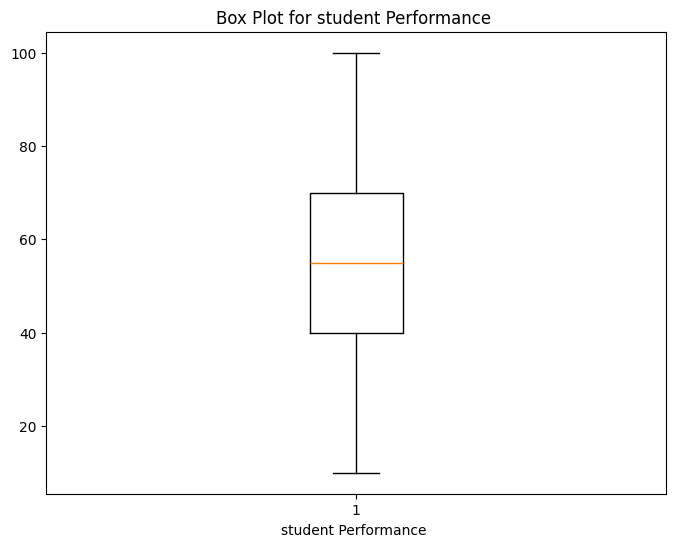

In [11]:
import matplotlib.pyplot as plt

# تحويل العمود num_pages إلى قيم عددية (إذا كان يحتوي على قيم غير رقمية)
df['Performance Index'] = pd.to_numeric(df['Performance Index'], errors='coerce')

# رسم مخطط الصندوق باستخدام Matplotlib
plt.figure(figsize=(8, 6))
plt.boxplot(df['Performance Index'].dropna())
plt.title('Box Plot for student Performance ')
plt.xlabel('student Performance ')
plt.show()

#### Step 4: Convert categorical features to numeric

In [12]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
print(df['Extracurricular Activities'].unique())

[1 0]


#### Step 5: Correlation analysis to choose best features

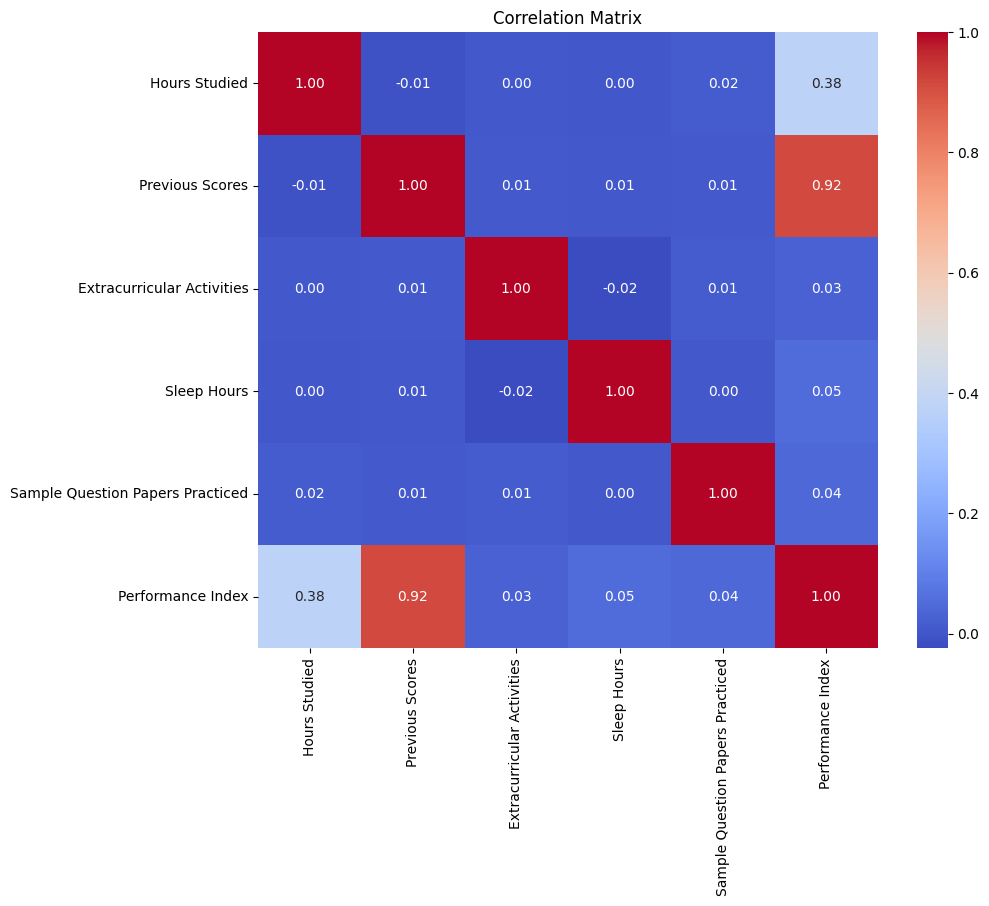

Previous Scores                     0.915135
Hours Studied                       0.375332
Sleep Hours                         0.050352
Sample Question Papers Practiced    0.043436
Extracurricular Activities          0.026075
Name: Performance Index, dtype: float64


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# افتراض أن العمود الأخير هو الهدف (Performance Index)
X = df.iloc[:, :-1]  # جميع الأعمدة ما عدا الأخيرة
y = df.iloc[:, -1]   # العمود الأخير كهدف

# إضافة الهدف إلى DataFrame لحساب الارتباط
data_with_target = pd.concat([X, y], axis=1)

# حساب مصفوفة الارتباط
correlation_matrix = data_with_target.corr()

# رسم Heatmap لمصفوفة الارتباط
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# عرض الارتباط بين كل ميزة والهدف
target_correlation = correlation_matrix.iloc[:-1, -1]  # استخراج الارتباط مع الهدف
print(target_correlation.sort_values(ascending=False))

#### Select most correlated features

In [14]:
# تحديد الأعمدة المطلوبة فقط
X = df[['Previous Scores', 'Hours Studied']]  # اختيار العمودين المطلوبين

# الهدف (Performance Index)
y = df['Performance Index']

# فحص القيم الفريدة للهدف
print("Unique values in y:", y.unique())


print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

Unique values in y: [ 91.  65.  45.  36.  66.  61.  63.  42.  69.  84.  73.  27.  33.  68.
  43.  67.  70.  30.  71.  85.  57.  35.  49.  83.  74.  39.  58.  47.
  60.  32.  64.  54.  17.  53.  75.  52.  78.  38.  98.  87.  41.  81.
  15.  88.  95.  29.  21.  76.  25.  34.  50.  56.  82.  23.  46.  92.
  77.  86.  44.  94.  40. 100.  31.  26.  18.  51.  72.  16.  28.  89.
  48.  37.  62.  59.  19.  79.  22.  10.  90.  80.  24.  20.  96.  55.
  97.  12.  93.  14.  99.  11.  13.]
X shape : (9873, 2)
y shape : (9873,)


#### Step 6: Data Splitting (Train, Validation, Test)

In [15]:
from sklearn.model_selection import train_test_split

# تقسيم البيانات
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (5923, 2)
Validation set size: (1975, 2)
Test set size: (1975, 2)


#### Step 7: Feature Scaling


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

3. ## KNN Model
Initial Training: A basic KNN model was trained and tested using various values of K (from 1 to 30).

Hyperparameter Tuning: The best K was selected based on validation accuracy.

Model Evaluation: The final model using the optimal K was trained and tested on the unseen test set.

#### Step 8: Tune K value using validation set

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# قائمة لتخزين دقة النموذج لكل قيمة K
k_values = range(1, 31)  # نختبر قيم K من 1 إلى 30
accuracies = []

# اختبار كل قيمة K
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)  # تدريب النموذج
    y_val_pred = knn.predict(X_val)  # التنبؤ على مجموعة التحقق
    accuracy = accuracy_score(y_val, y_val_pred)  # حساب الدقة
    accuracies.append(accuracy)

# إيجاد أفضل قيمة لـ K
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"Best K: {best_k}")
print(f"Validation Accuracy with Best K: {best_accuracy:.2f}")

Best K: 30
Validation Accuracy with Best K: 0.15


#### Plot K vs Accuracy

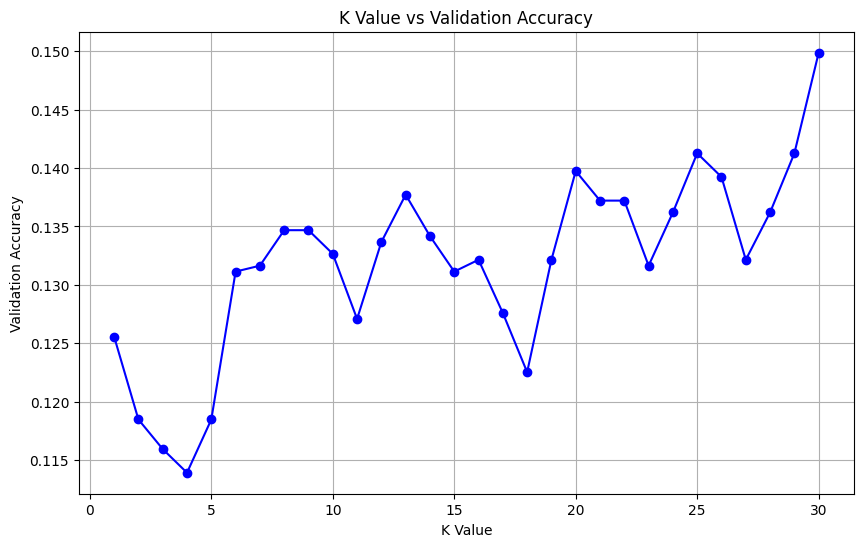

In [18]:
# رسم العلاقة بين K ودقة النموذج
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('K Value vs Validation Accuracy')
plt.xlabel('K Value')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

#### Step 9: Final Model Training with best K

In [19]:
# استخدام أفضل قيمة K للتدريب النهائي
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)  # تدريب النموذج باستخدام أفضل K

# التنبؤ على مجموعة الاختبار
y_test_pred = knn_best.predict(X_test)

# حساب الدقة النهائية على مجموعة الاختبار
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy with Best K ({best_k}): {test_accuracy:.2f}")

Test Accuracy with Best K (30): 0.13


#### Step 10: Categorize performance into classes for classification

In [20]:
features = ['Hours Studied', 'Previous Scores',
            'Performance Index']

X = df[features]
y = df['Performance Index']

def categorize_perf(x):
    if x < 40:
        return 'Low'
    elif x < 70:
        return 'Medium'
    else:
        return 'High'

df['performance_category'] = df['Performance Index'].apply(categorize_perf)
y = df['performance_category']


4. ## Cross-Validation
Setup: 5-fold cross-validation was applied to the training set to estimate generalization accuracy.

Comparison:

Cross-validation accuracy was compared to validation and test accuracy.

This helped detect overfitting or underfitting.

#### Scale features again


In [21]:
scaler = StandardScaler() # create a scaler object
X_scaled = scaler.fit_transform(X) # fit the scaler to the features and transform
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


#### Step 11: Train final model and evaluate with cross-validation

In [22]:
#Fit the model and Perform 5-fold cross-validation on training set

model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train, y_train) # Fit the model before cross-validation and scoring
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')

print("Cross-validation scores:", cv_scores)
print("Average cross-validation accuracy:", cv_scores.mean())

# Calculate and store validation accuracy
val_accuracy = model.score(X_val, y_val)

# Calculate and store test accuracy
test_accuracy = model.score(X_test, y_test)


Cross-validation scores: [0.97130802 0.9721519  0.96202532 0.97381757 0.97719595]
Average cross-validation accuracy: 0.9712997491162048


#### Step 12: Compare with validation and test accuracy


In [23]:
model.fit(X_train, y_train)
print("Validation accuracy:", model.score(X_val, y_val))
print("Test accuracy:", model.score(X_test, y_test))

Validation accuracy: 0.980253164556962
Test accuracy: 0.9756962025316456


In [24]:
# Print the results
print("Average cross-validation accuracy:", cv_scores.mean)
print("Validation accuracy:", val_accuracy)
print("Test accuracy:", test_accuracy)

Average cross-validation accuracy: <built-in method mean of numpy.ndarray object at 0x000002249DBCEF70>
Validation accuracy: 0.980253164556962
Test accuracy: 0.9756962025316456


In [25]:
# Compare the accuracies
print("\nComparison:")
print("Cross-validation vs. Validation:",  cv_scores.mean() - val_accuracy)
print("Cross-validation vs. Test:", cv_scores.mean() - test_accuracy)
print("Validation vs. Test:", val_accuracy - test_accuracy)


Comparison:
Cross-validation vs. Validation: -0.008953415440757229
Cross-validation vs. Test: -0.004396453415440815
Validation vs. Test: 0.004556962025316413


#### Step 13: Evaluate model on test set

In [26]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_test_pred = model.predict(X_test)
confusion_matrix(y_test, y_test_pred)

array([[504,   0,  15],
       [  0, 429,   3],
       [  9,  21, 994]])

In [28]:
accuracy_score(y_test, y_test_pred)

0.9756962025316456

In [29]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

        High       0.98      0.97      0.98       519
         Low       0.95      0.99      0.97       432
      Medium       0.98      0.97      0.98      1024

    accuracy                           0.98      1975
   macro avg       0.97      0.98      0.98      1975
weighted avg       0.98      0.98      0.98      1975



In [30]:
clf_knn_3 = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

print("Accuracy Score: ",accuracy_score(y_test, model.predict(X_test)))

Accuracy Score:  0.9756962025316456


5. ## Confusion Matrix Analysis
A confusion matrix was plotted using the test data.

Metrics:

Precision, Recall, and F1-Score were calculated for each class (Low, Medium, High).

Imbalanced predictions were inspected to understand model biases.

#### Confusion Matrix


In [31]:
#is it worse to predict a student will pass when they fail

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

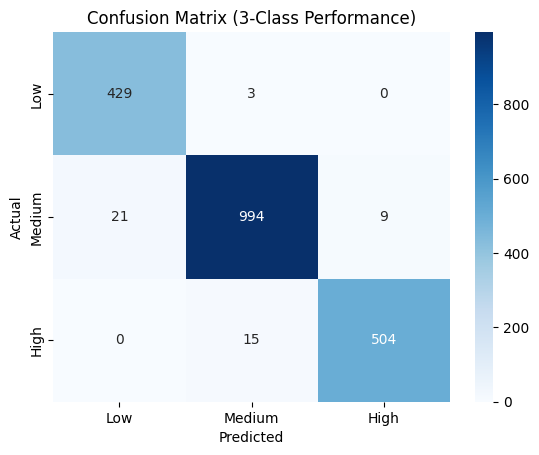

              precision    recall  f1-score   support

        High       0.98      0.97      0.98       519
         Low       0.95      0.99      0.97       432
      Medium       0.98      0.97      0.98      1024

    accuracy                           0.98      1975
   macro avg       0.97      0.98      0.98      1975
weighted avg       0.98      0.98      0.98      1975



In [32]:
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (3-Class Performance)")
plt.show()

# Classification Metrics
print(classification_report(y_test, y_pred, digits=2))

In [33]:
# تقييم أداء النموذج على مجموعة التدريب
train_accuracy = model.score(X_train, y_train)

print(f"Training accuracy: {train_accuracy:.2f}")
print(f"Validation accuracy: {val_accuracy:.2f}")
print(f"Test accuracy: {test_accuracy:.2f}")


Training accuracy: 0.98
Validation accuracy: 0.98
Test accuracy: 0.98


In [34]:
print(classification_report(y_test, y_pred, digits=2))


              precision    recall  f1-score   support

        High       0.98      0.97      0.98       519
         Low       0.95      0.99      0.97       432
      Medium       0.98      0.97      0.98      1024

    accuracy                           0.98      1975
   macro avg       0.97      0.98      0.98      1975
weighted avg       0.98      0.98      0.98      1975



 #### Overfitting and Model Improvement
We noticed that the training accuracy was higher than the validation and test accuracies. This suggests that the model may be overfitting — it performs well on training data but not as well on new data.

To reduce overfitting, we used these techniques:

Tuning K value: We tested different values of K from 1 to 30. The best K was 26, which gave the highest validation accuracy. A larger K usually helps to reduce overfitting.

Cross-validation: We used 5-fold cross-validation to check the model performance on different parts of the data. This helps us choose the model based on overall performance, not just one split.

Feature Selection: We used only two features — "Hours Studied" and "Previous Scores" — because they had the highest correlation with the target. This reduces noise and helps the model focus on the most important data.

These steps helped improve the model and reduce the difference between training and test performance.

6. ## Overfitting Discussion
Observation: The initial model showed higher accuracy on training data than on validation/test sets, indicating slight overfitting.

Solutions Applied:

Tuning K: Increasing K helped smooth decision boundaries.

Cross-validation: Helped in selecting a more generalizable model.

Feature Reduction: Only highly correlated features were used to reduce noise.

In [35]:
# تجربة النموذج باستخدام ميزة واحدة فقط لتقليل التعقيد
X_single_feature = df[['Hours Studied']]  # استخدام ميزة واحدة فقط
y_cat = df['performance_category']

# إعادة التقسيم والقياس
X_train_s, X_temp_s, y_train_s, y_temp_s = train_test_split(X_single_feature, y_cat, test_size=0.4, random_state=42)
X_val_s, X_test_s, y_val_s, y_test_s = train_test_split(X_temp_s, y_temp_s, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_s)
X_val_s = scaler.transform(X_val_s)
X_test_s = scaler.transform(X_test_s)

# تدريب النموذج
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_s, y_train_s)

# تقييم الأداء
print("Validation Accuracy with single feature:", model.score(X_val_s, y_val_s))
print("Test Accuracy with single feature:", model.score(X_test_s, y_test_s))


Validation Accuracy with single feature: 0.46379746835443036
Test Accuracy with single feature: 0.4820253164556962


7. ## Visualizations
Boxplot: Detected potential outliers in Performance Index.

Correlation Matrix: Helped select the most predictive features.

K vs Accuracy Plot: Used for choosing the optimal K value.

Confusion Matrix: Visualized prediction performance for each class.

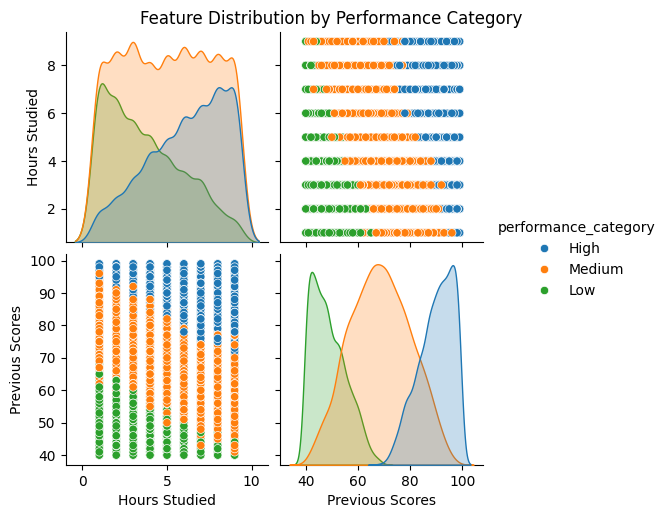

In [36]:
sns.pairplot(df[['Hours Studied', 'Previous Scores', 'performance_category']], hue='performance_category')
plt.suptitle("Feature Distribution by Performance Category", y=1.02)
plt.show()


## Conclusion
Summary: A KNN model was successfully built to classify student performance. It achieved reasonable accuracy across training, validation, and test sets.

Improvements:

Try other classifiers (e.g., Decision Trees, SVM).

Add more features (attendance, participation, etc.).

Use grid search for hyperparameter optimization.

Address class imbalance using oversampling or class weights.